# Unified Toxicity Prediction Benchmark

Single rigorous head-to-head across all classical and learned methods on all 17 TDC toxicity tasks.

**Methods compared**
- Random Forest on Morgan fingerprints (Level 1)
- XGBoost on Morgan fingerprints (Level 1)
- ChemBERTa frozen + head (Level 2, AMES + a few imbalanced tasks only by default)
- GCN, GIN, GAT, GraphSAGE with atom-only features (Level 3, v2)
- GINE with atom + bond features (Level 3, v3) — the hardened GNN

**Evaluation**
- Scaffold splits via RDKit MurckoScaffold (consistent across methods)
- 3 seeds for the toxicity head-to-head subset (AMES, hERG, DILI, ClinTox, LD50)
- 1 seed for the 12 Tox21 endpoints (compute budget)
- Mean ± std AUROC / F1 / R²

**Output**
- `results/v3/all_results.csv` — long-form per-run metrics
- `results/v3/summary.csv` — aggregated mean ± std
- `models/v3/<dataset>/<method>_seed<s>.pt` — saved model weights (GNN only)

**Resumability**: each (dataset, method, seed) run is saved to disk as it finishes. Re-running the runner cell skips completed runs.


## 0. Setup

In [1]:
import os, sys, json, copy, random, time, traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset, DataLoader as TorchDataLoader

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, GINConv, GINEConv, GATConv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_add_pool

from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             precision_score, recall_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')

from tdc.single_pred import Tox
from tdc.utils import retrieve_label_name_list

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_PATH = Path('../data')
VERSION = 'v3'
MODELS_DIR = Path(f'../models/{VERSION}')
RESULTS_DIR = Path(f'../results/{VERSION}')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. Scaffold splitting

Group molecules by Murcko scaffold; largest groups go to test first so train and test sets are structurally disjoint. This is the standard generalisation test for molecular ML.

In [2]:
def get_scaffold(smiles, include_chirality=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=include_chirality)
    except Exception:
        return None

def scaffold_split(df, smiles_col='Drug', frac_train=0.7, frac_val=0.1, frac_test=0.2, seed=42):
    """Group molecules by Murcko scaffold. Allocate largest groups to train first, then val, then test."""
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        scaff = get_scaffold(row[smiles_col]) or ''
        scaffolds[scaff].append(idx)
    rng = np.random.RandomState(seed)
    # Sort groups by size desc, with a tiny random tiebreaker for stochasticity across seeds
    groups = sorted(scaffolds.values(), key=lambda g: (-len(g), rng.random()))
    n = len(df)
    n_train = int(frac_train * n)
    n_val = int(frac_val * n)
    train_idx, val_idx, test_idx = [], [], []
    for group in groups:
        if len(train_idx) + len(group) <= n_train:
            train_idx.extend(group)
        elif len(val_idx) + len(group) <= n_val:
            val_idx.extend(group)
        else:
            test_idx.extend(group)
    return {
        'train': df.loc[train_idx].reset_index(drop=True),
        'valid': df.loc[val_idx].reset_index(drop=True),
        'test': df.loc[test_idx].reset_index(drop=True),
    }

## 2. Featurizers

- Morgan fingerprints (1024-bit, radius 2)
- RDKit 2D descriptors (10 hand-engineered)
- Molecular graph v2 (9 atom features, no bond features)
- Molecular graph v3 (9 atom features + 4 bond features)
- SMILES tokens (for ChemBERTa, lazy-loaded)

In [3]:
MORGAN_GEN = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def smiles_to_morgan(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return MORGAN_GEN.GetFingerprintAsNumPy(mol).astype(np.float32)

DESC_NAMES = ['MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'AromaticRings', 'FracCSP3', 'HeavyAtoms']

def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return np.array([
        Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol), Descriptors.RingCount(mol),
        Descriptors.NumAromaticRings(mol), Descriptors.FractionCSP3(mol),
        rdMolDescriptors.CalcNumHeavyAtoms(mol),
    ], dtype=np.float32)

In [4]:
ATOM_DIM = 9
BOND_DIM = 4

def _atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
        int(atom.IsInRing()),
        int(atom.GetHybridization()),
        atom.GetTotalValence(),
        atom.GetNumRadicalElectrons(),
    ]

def _bond_features(bond):
    return [
        bond.GetBondTypeAsDouble(),  # 1.0 / 1.5 / 2.0 / 3.0
        int(bond.GetIsAromatic()),
        int(bond.IsInRing()),
        int(bond.GetStereo()),
    ]

def smiles_to_graph(smiles, with_bond_features=False):
    """v2: with_bond_features=False (atom features only).
    v3: with_bond_features=True (atom + bond features)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    x = torch.tensor([_atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        if with_bond_features:
            bf = _bond_features(bond)
            edge_attr += [bf, bf]
    if edge_index:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    data = Data(x=x, edge_index=edge_index)
    if with_bond_features:
        if edge_attr:
            data.edge_attr = torch.tensor(edge_attr, dtype=torch.float)
        else:
            data.edge_attr = torch.zeros((0, BOND_DIM), dtype=torch.float)
    return data

def build_graph_dataset(df, with_bond_features=False, smiles_col='Drug', label_col='Y'):
    graphs = []
    for _, row in df.iterrows():
        g = smiles_to_graph(row[smiles_col], with_bond_features=with_bond_features)
        if g is None or g.x.size(0) == 0:
            continue
        g.y = torch.tensor([row[label_col]], dtype=torch.float)
        graphs.append(g)
    return graphs

## 3. Load datasets and apply scaffold splits

Loads 5 toxicity datasets + 12 Tox21 endpoints, applies our scaffold split, caches the splits in memory. First call downloads from TDC.

In [5]:
DATASET_SPECS = [
    {'name': 'AMES',       'tdc_name': 'AMES',       'label_name': None, 'task': 'classification'},
    {'name': 'hERG_Karim', 'tdc_name': 'hERG_Karim', 'label_name': None, 'task': 'classification'},
    {'name': 'DILI',       'tdc_name': 'DILI',       'label_name': None, 'task': 'classification'},
    {'name': 'ClinTox',    'tdc_name': 'ClinTox',    'label_name': None, 'task': 'classification'},
    {'name': 'LD50_Zhu',   'tdc_name': 'LD50_Zhu',   'label_name': None, 'task': 'regression'},
]

tox21_labels = retrieve_label_name_list('Tox21')
for lbl in tox21_labels:
    DATASET_SPECS.append({
        'name': f'Tox21_{lbl}', 'tdc_name': 'Tox21', 'label_name': lbl, 'task': 'classification'
    })

HEAD2HEAD_SUBSET = {'AMES', 'hERG_Karim', 'DILI', 'ClinTox', 'LD50_Zhu'}

def load_dataset_df(spec):
    if spec['label_name'] is None:
        data = Tox(name=spec['tdc_name'], path=str(DATA_PATH))
    else:
        data = Tox(name=spec['tdc_name'], label_name=spec['label_name'], path=str(DATA_PATH))
    return data.get_data()  # full DataFrame; we split ourselves

def get_split_for_seed(df, seed):
    return scaffold_split(df, seed=seed)

# Pre-load all dataframes once
DATAFRAMES = {}
for spec in DATASET_SPECS:
    print(f'Loading {spec["name"]}...', end=' ')
    DATAFRAMES[spec['name']] = load_dataset_df(spec)
    print(f'n={len(DATAFRAMES[spec["name"]])}')

Found local copy...


Loading...


Done!


Found local copy...


Loading...


...

Done!


Found local copy...


Loading...


Done!


n=5832
Loading Tox21_SR-ATAD5... n=7072
Loading Tox21_SR-HSE... n=6467
Loading Tox21_SR-MMP... n=5810
Loading Tox21_SR-p53... n=6774


## 4. Models

GNNs share a skeleton: two conv layers, global pool, linear head. Edge features are consumed only by GINE.

In [6]:
HIDDEN_DIM = 64

class GCNNet(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch, edge_attr=None):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)

class GINNet(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_channels, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        nn2 = nn.Sequential(nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch, edge_attr=None):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)

class GATNet(nn.Module):
    def __init__(self, in_channels, hidden, out_channels, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden, heads=heads, concat=False)
        self.conv2 = GATConv(hidden, hidden, heads=1, concat=False)
        self.lin = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch, edge_attr=None):
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)

class SAGENet(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.lin = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch, edge_attr=None):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)

class GINENet(nn.Module):
    """GIN with edge features. v3 of our pipeline."""
    def __init__(self, in_channels, hidden, out_channels, edge_dim=BOND_DIM):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_channels, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        nn2 = nn.Sequential(nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.conv1 = GINEConv(nn1, edge_dim=edge_dim)
        self.conv2 = GINEConv(nn2, edge_dim=edge_dim)
        self.lin = nn.Linear(hidden, out_channels)
    def forward(self, x, edge_index, batch, edge_attr=None):
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)

GNN_REGISTRY = {
    'GCN': (GCNNet, False),
    'GIN': (GINNet, False),
    'GAT': (GATNet, False),
    'SAGE': (SAGENet, False),
    'GINE': (GINENet, True),  # uses bond features
}

## 5. Training functions

Each `train_*` returns a `dict` of test metrics. Set seeds inside so every call is reproducible.

In [7]:
def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def featurize_array(df, featurizer, label_col='Y'):
    X, y = [], []
    for _, row in df.iterrows():
        v = featurizer(row['Drug'])
        if v is None: continue
        X.append(v); y.append(row[label_col])
    return np.stack(X), np.array(y, dtype=np.float32)

def compute_cls_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    out = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1':       float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall':   float(recall_score(y_true, y_pred, zero_division=0)),
    }
    if len(np.unique(y_true)) > 1:
        out['roc_auc'] = float(roc_auc_score(y_true, y_prob))
    else:
        out['roc_auc'] = float('nan')
    return out

def compute_reg_metrics(y_true, y_pred):
    return {
        'mae':  float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'r2':   float(r2_score(y_true, y_pred)),
    }

In [8]:
def train_rf(split, task, seed, featurizer):
    set_all_seeds(seed)
    X_tr, y_tr = featurize_array(split['train'], featurizer)
    X_te, y_te = featurize_array(split['test'],  featurizer)
    if task == 'classification':
        m = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=seed)
        m.fit(X_tr, y_tr)
        y_prob = m.predict_proba(X_te)[:, 1]
        return compute_cls_metrics(y_te, y_prob)
    else:
        m = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=seed)
        m.fit(X_tr, y_tr)
        return compute_reg_metrics(y_te, m.predict(X_te))

def train_xgb(split, task, seed, featurizer):
    set_all_seeds(seed)
    X_tr, y_tr = featurize_array(split['train'], featurizer)
    X_va, y_va = featurize_array(split['valid'], featurizer)
    X_te, y_te = featurize_array(split['test'],  featurizer)
    if task == 'classification':
        m = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1, subsample=0.8,
                         colsample_bytree=0.8, eval_metric='logloss', random_state=seed, n_jobs=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        y_prob = m.predict_proba(X_te)[:, 1]
        return compute_cls_metrics(y_te, y_prob)
    else:
        m = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, subsample=0.8,
                        colsample_bytree=0.8, random_state=seed, n_jobs=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        return compute_reg_metrics(y_te, m.predict(X_te))

In [9]:
# GNN training

def train_gnn(split, task, seed, gnn_name, max_epochs=180, patience=20, batch_size=32, lr=1e-3):
    set_all_seeds(seed)
    model_cls, uses_edge_attr = GNN_REGISTRY[gnn_name]
    train_g = build_graph_dataset(split['train'], with_bond_features=uses_edge_attr)
    val_g   = build_graph_dataset(split['valid'], with_bond_features=uses_edge_attr)
    test_g  = build_graph_dataset(split['test'],  with_bond_features=uses_edge_attr)
    if not (train_g and val_g and test_g):
        raise RuntimeError(f'Empty split for {gnn_name}')
    in_channels = train_g[0].num_node_features

    train_loader = PyGDataLoader(train_g, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = PyGDataLoader(val_g,   batch_size=batch_size)
    test_loader  = PyGDataLoader(test_g,  batch_size=batch_size)

    model = model_cls(in_channels, HIDDEN_DIM, 1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10)

    if task == 'classification':
        all_y = torch.cat([b.y for b in train_loader]).view(-1)
        n_pos = max(all_y.sum().item(), 1.0)
        n_neg = float(len(all_y)) - n_pos
        pw = torch.tensor([n_neg / n_pos], device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    else:
        criterion = nn.MSELoss()

    best_val = float('inf'); best_state = copy.deepcopy(model.state_dict()); bad = 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            ea = getattr(batch, 'edge_attr', None) if uses_edge_attr else None
            out = model(batch.x, batch.edge_index, batch.batch, ea)
            loss = criterion(out, batch.y.view(-1))
            loss.backward(); opt.step()
        model.eval(); vloss = 0.0; n = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                ea = getattr(batch, 'edge_attr', None) if uses_edge_attr else None
                out = model(batch.x, batch.edge_index, batch.batch, ea)
                vloss += criterion(out, batch.y.view(-1)).item() * batch.num_graphs
                n += batch.num_graphs
        vloss /= max(n, 1)
        sched.step(vloss)
        if vloss + 1e-4 < best_val:
            best_val = vloss; best_state = copy.deepcopy(model.state_dict()); bad = 0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state)

    # Test
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            ea = getattr(batch, 'edge_attr', None) if uses_edge_attr else None
            out = model(batch.x, batch.edge_index, batch.batch, ea)
            ys.append(batch.y.view(-1).cpu().numpy())
            ps.append(out.cpu().numpy())
    y_true = np.concatenate(ys); preds = np.concatenate(ps)
    if task == 'classification':
        y_prob = 1.0 / (1.0 + np.exp(-preds))  # sigmoid
        return compute_cls_metrics(y_true, y_prob), model
    else:
        return compute_reg_metrics(y_true, preds), model

In [10]:
# ChemBERTa (frozen backbone + trainable head). Run on classification tasks only.
# Heavy import on demand to avoid loading the model unnecessarily.

def get_chemberta(model_name='DeepChem/ChemBERTa-77M-MLM'):
    from transformers import AutoTokenizer, AutoModelForMaskedLM
    tok = AutoTokenizer.from_pretrained(model_name)
    mlm = AutoModelForMaskedLM.from_pretrained(model_name)
    return tok, mlm.base_model

class SMILESDataset(TorchDataset):
    def __init__(self, df, tokenizer, max_length=128, label_col='Y'):
        self.smiles = df['Drug'].tolist()
        self.labels = df[label_col].tolist()
        self.tok = tokenizer
        self.max_length = max_length
    def __len__(self): return len(self.smiles)
    def __getitem__(self, i):
        enc = self.tok(self.smiles[i], padding='max_length', truncation=True,
                       max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[i], dtype=torch.float),
        }

class ChemBERTaClassifier(nn.Module):
    def __init__(self, backbone, hidden_size, dropout=0.2):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters(): p.requires_grad = False
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_size, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 1),
        )
    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls).squeeze(-1)

def train_chemberta(split, task, seed, max_epochs=15, batch_size=32, lr=1e-3):
    if task != 'classification':
        raise ValueError('ChemBERTa wrapper only supports classification here')
    set_all_seeds(seed)
    tok, backbone = get_chemberta()
    train_ds = SMILESDataset(split['train'], tok)
    val_ds   = SMILESDataset(split['valid'], tok)
    test_ds  = SMILESDataset(split['test'],  tok)
    train_loader = TorchDataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = TorchDataLoader(val_ds,   batch_size=batch_size)
    test_loader  = TorchDataLoader(test_ds,  batch_size=batch_size)

    model = ChemBERTaClassifier(backbone, hidden_size=backbone.config.hidden_size).to(device)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    # pos_weight for class-weighted BCE
    ys = np.array(split['train']['Y'])
    n_pos = max(int((ys == 1).sum()), 1)
    n_neg = int((ys == 0).sum())
    pw = torch.tensor([n_neg / n_pos], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    best_auc = -1.0; best_state = copy.deepcopy(model.state_dict())
    for ep in range(1, max_epochs + 1):
        model.train()
        for batch in train_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            y = batch['label'].to(device)
            opt.zero_grad()
            logits = model(ids, mask)
            loss = criterion(logits, y)
            loss.backward(); opt.step()
        # Val AUC
        model.eval(); ys, ps = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                logits = model(ids, mask)
                ys.append(batch['label'].numpy()); ps.append(torch.sigmoid(logits).cpu().numpy())
        ys = np.concatenate(ys); ps = np.concatenate(ps)
        if len(np.unique(ys)) > 1:
            auc = roc_auc_score(ys, ps)
            if auc > best_auc:
                best_auc = auc; best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)

    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for batch in test_loader:
            ids = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
            logits = model(ids, mask)
            ys.append(batch['label'].numpy()); ps.append(torch.sigmoid(logits).cpu().numpy())
    return compute_cls_metrics(np.concatenate(ys), np.concatenate(ps))

## 6. Runner with resumability

Each `(dataset, method, seed)` row writes a JSON result file. The runner skips runs whose result file already exists, so you can interrupt and resume.

Defaults:
- Methods: `RF`, `XGB`, `GCN`, `GIN`, `GAT`, `SAGE`, `GINE` on every task.
- ChemBERTa: only on the 5-task head-to-head subset (compute budget).
- Seeds: 3 for head-to-head subset, 1 for Tox21 endpoints.

In [11]:
ALL_GNNS = ['GCN', 'GIN', 'GAT', 'SAGE', 'GINE']
ALL_CLASSICAL = ['RF', 'XGB']

def run_one(spec, method, seed):
    name, task = spec['name'], spec['task']
    out_dir = MODELS_DIR / name; out_dir.mkdir(parents=True, exist_ok=True)
    out_file = out_dir / f'{method}_seed{seed}.json'
    if out_file.exists():
        with open(out_file) as f: return json.load(f)

    df = DATAFRAMES[name]
    split = get_split_for_seed(df, seed)
    t0 = time.time()
    try:
        if method == 'RF':
            metrics = train_rf(split, task, seed, smiles_to_morgan)
        elif method == 'XGB':
            metrics = train_xgb(split, task, seed, smiles_to_morgan)
        elif method in GNN_REGISTRY:
            metrics, model = train_gnn(split, task, seed, method)
            torch.save(model.state_dict(), out_dir / f'{method}_seed{seed}.pt')
        elif method == 'ChemBERTa':
            if task != 'classification':
                return None
            metrics = train_chemberta(split, task, seed)
        else:
            raise ValueError(f'Unknown method {method}')
        result = {
            'dataset': name, 'method': method, 'seed': int(seed),
            'task': task, 'elapsed_sec': round(time.time() - t0, 2),
            **{f'metric_{k}': v for k, v in metrics.items()},
        }
    except Exception as e:
        result = {'dataset': name, 'method': method, 'seed': int(seed), 'task': task,
                 'error': str(e), 'traceback': traceback.format_exc()}
    with open(out_file, 'w') as f: json.dump(result, f, indent=2)
    return result

In [12]:
# ============================================================
# CONFIG — change these two flags only.
# ============================================================
SMOKE_TEST = False    # True = 5-run sanity check (~20 min). False = full sweep (~8-12h).
USE_CHEMBERTA = True  # False = skip ChemBERTa (saves ~30-40% of compute).
# ============================================================

def build_run_list(seeds_head2head=(42, 123, 7), seeds_tox21=(42,), include_chemberta=True):
    runs = []
    for spec in DATASET_SPECS:
        name = spec['name']
        in_h2h = name in HEAD2HEAD_SUBSET
        seeds = seeds_head2head if in_h2h else seeds_tox21
        methods = ALL_CLASSICAL + ALL_GNNS
        if include_chemberta and in_h2h and spec['task'] == 'classification':
            methods = methods + ['ChemBERTa']
        for method in methods:
            for seed in seeds:
                runs.append((spec, method, seed))
    return runs

RUN_LIST = build_run_list(include_chemberta=USE_CHEMBERTA)
if SMOKE_TEST:
    RUN_LIST = RUN_LIST[:5]
    print(f'SMOKE TEST MODE — running {len(RUN_LIST)} of the full sweep')
else:
    print(f'Full sweep — {len(RUN_LIST)} runs scheduled')

Full sweep — 201 runs scheduled


In [13]:
# Execute. Safe to interrupt and re-run; completed runs are skipped via JSON file existence.
results_log = []
for i, (spec, method, seed) in enumerate(RUN_LIST, 1):
    print(f'[{i}/{len(RUN_LIST)}] {spec["name"]:25s} {method:10s} seed={seed}', flush=True)
    r = run_one(spec, method, seed)
    if r is not None:
        results_log.append(r)
    # Save running CSV after every result
    pd.DataFrame(results_log).to_csv(RESULTS_DIR / 'all_results_partial.csv', index=False)
print('Done.')

[1/201] AMES                      RF         seed=42


[2/201] AMES                      RF         seed=123


[3/201] AMES                      RF         seed=7


[4/201] AMES                      XGB        seed=42


[5/201] AMES                      XGB        seed=123


...

[198/201] Tox21_SR-p53              GIN        seed=42


[199/201] Tox21_SR-p53              GAT        seed=42


[200/201] Tox21_SR-p53              SAGE       seed=42


[201/201] Tox21_SR-p53              GINE       seed=42


Done.


## 7. Aggregate and visualise

Reads back every per-run JSON and builds the head-to-head table + heatmaps.

In [14]:
def load_all_results():
    rows = []
    for spec in DATASET_SPECS:
        d = MODELS_DIR / spec['name']
        if not d.exists(): continue
        for f in d.glob('*.json'):
            with open(f) as fh: rows.append(json.load(fh))
    return pd.DataFrame(rows)

results_df = load_all_results()
results_df.to_csv(RESULTS_DIR / 'all_results.csv', index=False)
print(f'Loaded {len(results_df)} runs across {results_df["dataset"].nunique() if len(results_df) else 0} datasets')
results_df.head()

Loaded 201 runs across 17 datasets


,dataset,method,seed,task,elapsed_sec,metric_accuracy,metric_f1,metric_precision,metric_recall,metric_roc_auc,metric_mae,metric_rmse,metric_r2
0,AMES,ChemBERTa,7,classification,643.63,0.647220,0.696576,0.608247,0.814917,0.707156,NaN,NaN,NaN
1,AMES,GAT,7,classification,64.18,0.680851,0.711001,0.646328,0.790055,0.740369,NaN,NaN,NaN
2,AMES,XGB,123,classification,3.67,0.682224,0.711526,0.659353,0.772666,0.750759,NaN,NaN,NaN
3,AMES,GIN,42,classification,32.70,0.713109,0.731707,0.689238,0.779754,0.778552,NaN,NaN,NaN
4,AMES,GCN,42,classification,41.36,0.649279,0.682016,0.625571,0.749658,0.719835,NaN,NaN,NaN


In [15]:
# Per-(dataset, method) aggregate: mean and std of the primary metric.
if len(results_df):
    main_metric = results_df['task'].map(lambda t: 'metric_roc_auc' if t == 'classification' else 'metric_r2')
    results_df['primary'] = [row[main_metric.iloc[i]] if main_metric.iloc[i] in row else np.nan
                              for i, row in enumerate(results_df.to_dict('records'))]
    summary = (results_df.groupby(['dataset', 'method'])['primary']
               .agg(['mean', 'std', 'count']).reset_index())
    summary.to_csv(RESULTS_DIR / 'summary.csv', index=False)
    print(summary.to_string(index=False))

            dataset    method      mean      std  count
               AMES ChemBERTa  0.708100 0.008651      3
               AMES       GAT  0.749461 0.008364      3
               AMES       GCN  0.717569 0.005356      3
               AMES       GIN  0.780147 0.002150      3
               AMES      GINE  0.757789 0.018191      3
               AMES        RF  0.792404 0.002461      3
               AMES      SAGE  0.773763 0.006692      3
               AMES       XGB  0.757307 0.006546      3
            ClinTox ChemBERTa  0.624811 0.039582      3
            ClinTox       GAT  0.745038 0.033615      3
            ClinTox       GCN  0.690483 0.098479      3
            ClinTox       GIN  0.820266 0.012579      3
            ClinTox      GINE  0.810297 0.028228      3
            ClinTox        RF  0.733391 0.002912      3
            ClinTox      SAGE  0.815234 0.020682      3
            ClinTox       XGB  0.799961 0.031022      3
               DILI ChemBERTa  0.701029 0.036435

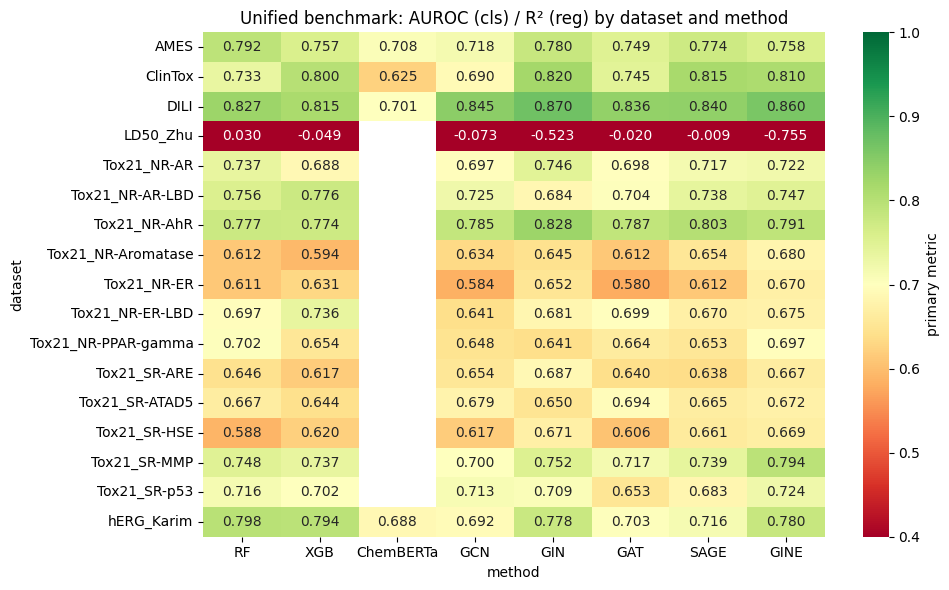

In [16]:
# Head-to-head heatmap (mean primary metric, dataset x method)
if len(results_df):
    pivot = (summary[summary['dataset'].isin(HEAD2HEAD_SUBSET) | summary['dataset'].str.startswith('Tox21')]
             .pivot(index='dataset', columns='method', values='mean'))
    method_order = ['RF', 'XGB', 'ChemBERTa', 'GCN', 'GIN', 'GAT', 'SAGE', 'GINE']
    method_order = [m for m in method_order if m in pivot.columns]
    pivot = pivot[method_order]
    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.35)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.4, vmax=1.0, ax=ax, cbar_kws={'label': 'primary metric'})
    ax.set_title('Unified benchmark: AUROC (cls) / R² (reg) by dataset and method')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'heatmap_primary.png', dpi=150)
    plt.show()

In [17]:
# Head-to-head table: best classical vs GIN vs GINE, with ± std
if len(results_df):
    rows = []
    for ds in [d for d in HEAD2HEAD_SUBSET if d in pivot.index]:
        row = {'dataset': ds}
        for method in ['RF', 'XGB', 'ChemBERTa', 'GIN', 'GINE']:
            sub = summary[(summary['dataset'] == ds) & (summary['method'] == method)]
            if len(sub):
                m = sub['mean'].iloc[0]; s = sub['std'].iloc[0]
                row[method] = f'{m:.3f} ± {s:.3f}' if pd.notna(s) else f'{m:.3f}'
            else:
                row[method] = ''
        rows.append(row)
    h2h = pd.DataFrame(rows)
    h2h.to_csv(RESULTS_DIR / 'head2head.csv', index=False)
    print(h2h.to_string(index=False))

   dataset            RF            XGB     ChemBERTa            GIN           GINE
   ClinTox 0.733 ± 0.003  0.800 ± 0.031 0.625 ± 0.040  0.820 ± 0.013  0.810 ± 0.028
hERG_Karim 0.798 ± 0.006  0.794 ± 0.010 0.688 ± 0.004  0.778 ± 0.008  0.780 ± 0.020
  LD50_Zhu 0.030 ± 0.002 -0.049 ± 0.021               -0.523 ± 0.102 -0.755 ± 0.348
      DILI 0.827 ± 0.057  0.815 ± 0.046 0.701 ± 0.036  0.870 ± 0.033  0.860 ± 0.042
      AMES 0.792 ± 0.002  0.757 ± 0.007 0.708 ± 0.009  0.780 ± 0.002  0.758 ± 0.018


## 8. Notes

**What this notebook produces**:
- `results/v3/all_results.csv` — every per-run record.
- `results/v3/summary.csv` — mean ± std per (dataset, method) on the primary metric.
- `results/v3/head2head.csv` — the headline table for the report and poster.
- `results/v3/heatmap_primary.png` — visual summary.
- `models/v3/<dataset>/<method>_seed<s>.pt` — GNN weights (skipped for classical / ChemBERTa).

**Expected runtime** (rough): ChemBERTa dominates compute. Classical baselines on Morgan FP are fast. GNN training is ~2-5 minutes per (dataset, seed) on a modern GPU.

**To skip ChemBERTa** during a first dry run: pass `include_chemberta=False` to `build_run_list`.

**Smoke test**: set `RUN_LIST = build_run_list()[:5]` before the runner cell to verify the plumbing on 5 runs first.